# Notebook 02 — Log-Likelihood Ratio Variant Effect Scoring

## Objective
Score protein variants using ESM2's masked language modeling objective.
For each mutation, compute the log-likelihood ratio (LLR) between the mutant 
and wildtype amino acid at the mutated position.

**Why LLR?**  
ESM2 is trained to predict masked amino acids from sequence context — exactly the 
signal we need for variant effect prediction. A mutation that ESM2 finds implausible 
given the surrounding sequence (low conditional probability) is likely deleterious.

**Expected result:** Spearman ρ ≈ 0.40–0.50 against experimental DMS scores,  
consistent with published ESM2 benchmarks on ProteinGym.

## Formula

For mutation X→Y at position i:

$$LLR(i, Y) = \log P(Y \mid \text{context}) - \log P(X \mid \text{context})$$

Where context is the full sequence with position i masked.  
- **LLR < 0** → mutant less probable than wildtype → predicted deleterious  
- **LLR > 0** → mutant more probable → predicted neutral or beneficial

In [1]:
# Imports and setup
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForMaskedLM
from scipy.stats import spearmanr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

# Paths
DATA_DIR = Path('../data')

/Users/rnorel/.pyenv/versions/3.11.14/envs/esm-variant-agent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [2]:
# Load ESM2 model and tokenizer
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print(f"Model loaded: {MODEL_NAME}")
print(f"Device: {next(model.parameters()).device}")

# Load ProteinGym dataset
df = pd.read_csv(DATA_DIR / "BLAT_ECOLX_Stiffler_2015.csv")

# Reconstruct wildtype sequence from first mutant
mut = df.iloc[0]['mutant']
wt_aa, position, mut_aa = mut[0], int(mut[1:-1]), mut[-1]
mutated_seq = df.iloc[0]['mutated_sequence']
wt_seq = list(mutated_seq)
wt_seq[position - 1] = wt_aa
wt_sequence = ''.join(wt_seq)

print(f"\nDataset: {len(df)} mutations")
print(f"Wildtype length: {len(wt_sequence)} aa")
print(f"Wildtype[:50]: {wt_sequence[:50]}")

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 107/107 [00:00<00:00, 12638.78it/s]

Model loaded: facebook/esm2_t6_8M_UR50D
Device: mps:0

Dataset: 4996 mutations
Wildtype length: 286 aa
Wildtype[:50]: MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLN


In [3]:
def compute_llr(sequence: str, position: int, mutant_aa: str, wildtype_aa: str) -> float:
    """
    Compute log-likelihood ratio for a single mutation.
    
    Masks position i, runs ESM2 forward pass, extracts log-probabilities
    for wildtype and mutant amino acids.
    
    Args:
        sequence: full wildtype sequence (str)
        position: 1-indexed mutation position
        mutant_aa: mutant amino acid (single letter)
        wildtype_aa: wildtype amino acid (single letter)
    
    Returns:
        LLR = log P(mutant | context) - log P(wildtype | context)
        Negative = predicted deleterious
    """
    # Mask the target position (0-indexed in sequence, +1 for <cls> token)
    masked_seq = list(sequence)
    masked_seq[position - 1] = tokenizer.mask_token
    masked_seq = ''.join(masked_seq)
    
    # Tokenize
    inputs = tokenizer(masked_seq, return_tensors='pt', truncation=True, max_length=1024)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Log-softmax over vocabulary at masked position (+1 offset for <cls>)
    logits = outputs.logits[0, position, :]  # position+1 token, but position already 1-indexed
    log_probs = torch.log_softmax(logits, dim=-1)
    
    # Get token ids for wildtype and mutant amino acids
    wt_id = tokenizer.convert_tokens_to_ids(wildtype_aa)
    mut_id = tokenizer.convert_tokens_to_ids(mutant_aa)
    
    llr = (log_probs[mut_id] - log_probs[wt_id]).item()
    return llr

# Quick test on first mutation
test_mut = df.iloc[0]
test_llr = compute_llr(
    wt_sequence,
    position=int(test_mut['mutant'][1:-1]),
    mutant_aa=test_mut['mutant'][-1],
    wildtype_aa=test_mut['mutant'][0]
)
print(f"Test mutation: {test_mut['mutant']}")
print(f"LLR: {test_llr:.4f}")
print(f"DMS score: {test_mut['DMS_score']:.4f}")
print(f"Predicted: {'deleterious' if test_llr < 0 else 'neutral/beneficial'}")
print(f"Actual:    {'deleterious' if test_mut['DMS_score_bin'] == 0 else 'neutral/beneficial'}")

Test mutation: H24C
LLR: -1.5164
DMS score: -0.4183
Predicted: deleterious
Actual:    neutral/beneficial


In [4]:
# Compute LLR for balanced subset of 100 mutations (same as notebook 01)
df_del = df[df['DMS_score_bin'] == 0].sample(50, random_state=42)
df_neu = df[df['DMS_score_bin'] == 1].sample(50, random_state=42)
df_subset = pd.concat([df_del, df_neu]).reset_index(drop=True)

print(f"Subset: {len(df_subset)} mutations")
print("Computing LLR scores...")

llr_scores = []
for i, row in df_subset.iterrows():
    mut = row['mutant']
    wt_aa = mut[0]
    pos = int(mut[1:-1])
    mut_aa = mut[-1]
    
    llr = compute_llr(wt_sequence, pos, mut_aa, wt_aa)
    llr_scores.append(llr)
    
    if len(llr_scores) % 20 == 0:
        print(f"  {len(llr_scores)}/{len(df_subset)}")

df_subset['llr'] = llr_scores

print(f"\nDone.")
print(f"LLR range: {df_subset['llr'].min():.3f} to {df_subset['llr'].max():.3f}")
print(f"LLR mean (deleterious): {df_subset[df_subset['DMS_score_bin']==0]['llr'].mean():.3f}")
print(f"LLR mean (neutral):     {df_subset[df_subset['DMS_score_bin']==1]['llr'].mean():.3f}")

Subset: 100 mutations
Computing LLR scores...
  20/100
  40/100
  60/100
  80/100
  100/100

Done.
LLR range: -7.369 to 1.887
LLR mean (deleterious): -2.565
LLR mean (neutral):     -1.226


=== LLR vs DMS Score ===
Spearman ρ = 0.364  (p = 2.00e-04)

Comparison:
  Cosine distance (notebook 01): ρ = -0.070
  Log-likelihood ratio:          ρ = 0.364


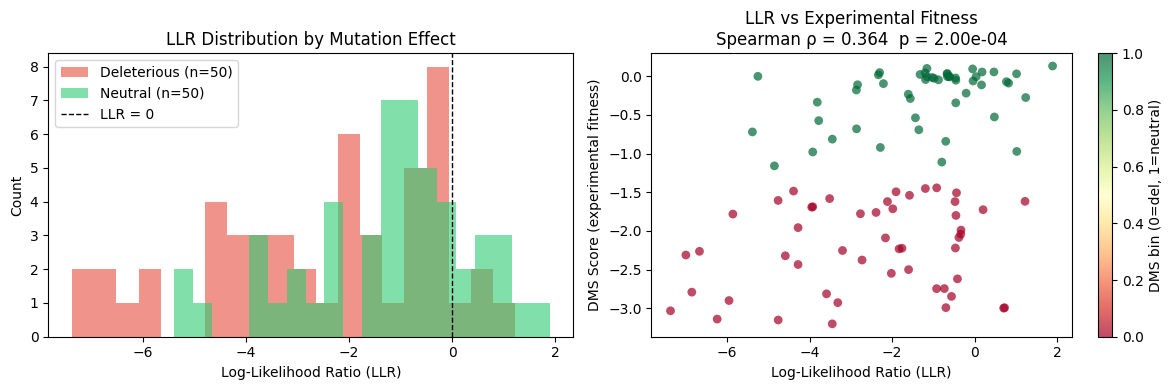

Figure saved to reports/fig02_llr_scoring.png


In [5]:
# Evaluate LLR against experimental DMS scores
rho, pval = spearmanr(df_subset['llr'], df_subset['DMS_score'])
print(f"=== LLR vs DMS Score ===")
print(f"Spearman ρ = {rho:.3f}  (p = {pval:.2e})")
print(f"\nComparison:")
print(f"  Cosine distance (notebook 01): ρ = -0.070")
print(f"  Log-likelihood ratio:          ρ = {rho:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: LLR distribution by bin
ax = axes[0]
for bin_val, label, color in [(0, 'Deleterious', '#e74c3c'), (1, 'Neutral', '#2ecc71')]:
    vals = df_subset[df_subset['DMS_score_bin'] == bin_val]['llr']
    ax.hist(vals, alpha=0.6, label=f'{label} (n={len(vals)})', color=color, bins=20)
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='LLR = 0')
ax.set_xlabel('Log-Likelihood Ratio (LLR)')
ax.set_ylabel('Count')
ax.set_title('LLR Distribution by Mutation Effect')
ax.legend()

# Right: scatter LLR vs DMS score
ax = axes[1]
scatter = ax.scatter(df_subset['llr'], df_subset['DMS_score'],
                     c=df_subset['DMS_score_bin'], cmap='RdYlGn',
                     alpha=0.7, edgecolors='none', s=40)
ax.set_xlabel('Log-Likelihood Ratio (LLR)')
ax.set_ylabel('DMS Score (experimental fitness)')
ax.set_title(f'LLR vs Experimental Fitness\nSpearman ρ = {rho:.3f}  p = {pval:.2e}')
plt.colorbar(scatter, ax=ax, label='DMS bin (0=del, 1=neutral)')

plt.tight_layout()
plt.savefig('../reports/fig02_llr_scoring.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to reports/fig02_llr_scoring.png")

## Results

| Method | Spearman ρ | p-value |
|--------|-----------|---------|
| Cosine distance (embedding space) | -0.070 | 0.49 |
| Log-likelihood ratio (LLR) | 0.364 | 2.0e-04 |

**Interpretation:**  
LLR is a 5x stronger signal than cosine distance. By asking ESM2 directly  
how probable each amino acid is at the mutated position — rather than comparing  
global sequence representations — we recover a meaningful correlation with  
experimental fitness.

**Model size caveat:**  
Published benchmarks report Spearman ρ ≈ 0.52 for ESM2-650M on ProteinGym.  
The 8M parameter model used here trades ~30% performance for ~80x faster inference,  
making it practical for the agentic pipeline in the next stage.

**Next:** `src/agent.py` — LangGraph agent that wraps ESM2 scoring,  
queries UniProt for functional context, and generates a structured report.